# Topic Modeling EDA


1. **Topic shares by year**
2. **Topic shares by season**
3. **Overall topic prevalence**

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import textwrap
from matplotlib.ticker import MultipleLocator

In [ ]:
DATA_PATH = Path("data/stylecom_cleaned.csv")

In [50]:
df = pd.read_csv(DATA_PATH)
df["year"] = pd.to_datetime(df["date"], format="%d-%b-%y").dt.year

years = sorted(df["year"].unique())
print(f"{len(df)} reviews, {df['designer'].nunique()} designers")
print(f"years {years[0]}-{years[-1]} (n = {len(years)})")
print()
print(df["season"].value_counts().to_string())

6501 reviews, 709 designers
years 1999-2014 (n = 16)

season
Fall      3364
Spring    3137


## 1. Topic shares by year

Look for humps before trusting a linear trend in 4.2 — a topic that rose and
then fell will have a near-zero linear coefficient despite clearly moving.

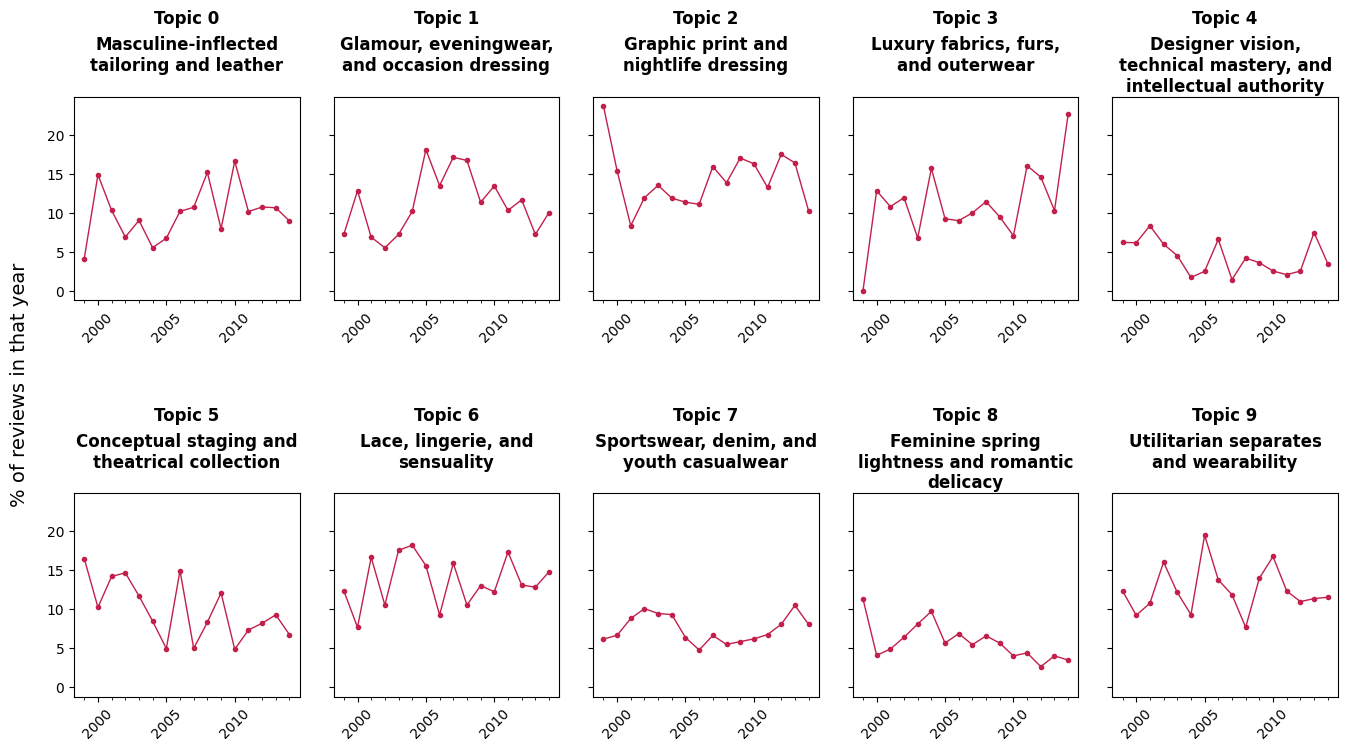

In [137]:
annotated = pd.read_csv("data/stylecom_cleaned_annotated.csv")
annotated["year"] = pd.to_datetime(annotated["date"], format="%d-%b-%y").dt.year

shares = pd.crosstab(annotated["year"], annotated["topic_number"], normalize="index") * 100

TOPIC_LABELS = {
    0: "Masculine-inflected tailoring and leather",
    1: "Glamour, eveningwear, and occasion dressing",
    2: "Graphic print and nightlife dressing",
    3: "Luxury fabrics, furs, and outerwear",
    4: "Designer vision, technical mastery, and intellectual authority",
    5: "Conceptual staging and theatrical collection",
    6: "Lace, lingerie, and sensuality",
    7: "Sportswear, denim, and youth casualwear",
    8: "Feminine spring lightness and romantic delicacy",
    9: "Utilitarian separates and wearability",
}

fig, axes = plt.subplots(2, 5, figsize=(16, 8), sharex=True, sharey=True)
for k, ax in zip(shares.columns, axes.flat):
    ax.plot(shares.index, shares[k], marker="o", markersize=3, color="#C2204B", linewidth=1)
    ax.xaxis.set_major_locator(MultipleLocator(5))
    ax.xaxis.set_minor_locator(MultipleLocator(1))
    # labelbottom=True forces the year ticks onto every panel; sharex would otherwise
    # hide them on the top row.
    ax.tick_params(axis="x", labelrotation=45, labelbottom=True)
    ax.text(0.5, 1.34, f"Topic {k}", transform=ax.transAxes,
            ha="center", va="bottom", fontweight="bold", fontsize=12)
    wrapped = "\n".join(textwrap.wrap(TOPIC_LABELS[k], width=24))
    ax.text(0.5, 1.30, wrapped, transform=ax.transAxes,
            ha="center", va="top", fontweight="bold", fontsize=12)
fig.supylabel("% of reviews in that year", x=0.07, fontsize= 14)
fig.subplots_adjust(left=0.11, hspace=0.95, wspace=0.15, top=0.86)
plt.show()

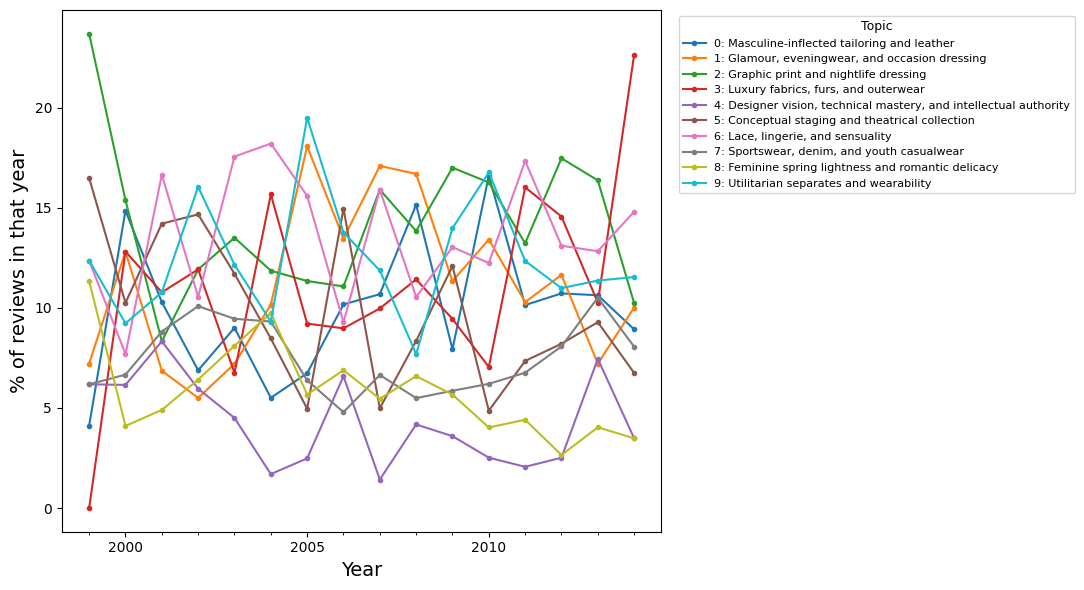

In [138]:
fig, ax = plt.subplots(figsize=(11, 6))
colors = plt.cm.tab10(range(len(shares.columns)))
for k, c in zip(shares.columns, colors):
    ax.plot(shares.index, shares[k], marker="o", markersize=3, color=c,
            label=f"{k}: {TOPIC_LABELS[k]}")
ax.set_xlabel("Year", fontsize=14)
ax.set_ylabel("% of reviews in that year", fontsize=14)
ax.tick_params(axis="both", labelsize=10)
ax.xaxis.set_major_locator(MultipleLocator(5))
ax.xaxis.set_minor_locator(MultipleLocator(1))
ax.legend(title="Topic", bbox_to_anchor=(1.02, 1), loc="upper left",
          fontsize=8, title_fontsize=9)
fig.tight_layout()
plt.show()

## 2. Topic shares by season

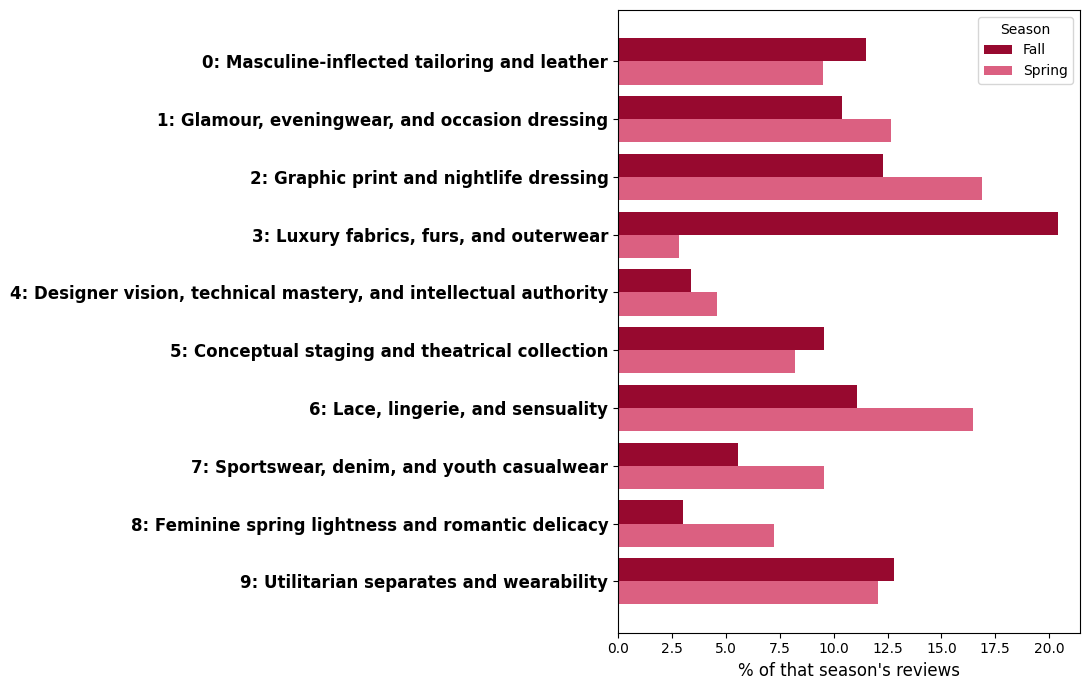

In [111]:
season_shares = pd.crosstab(annotated["season"], annotated["topic_number"], normalize="index") * 100

topics = list(shares.columns)
y = range(len(topics))
h = 0.4

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh([i - h / 2 for i in y], season_shares.loc["Fall", topics], height=h,
        label="Fall", color="#97092F")
ax.barh([i + h / 2 for i in y], season_shares.loc["Spring", topics], height=h,
        label="Spring", color="#DB6081")
ax.set_yticks(list(y))
ax.set_yticklabels([f"{k}: {TOPIC_LABELS[k]}" for k in topics], fontweight="bold", fontsize=12)
ax.invert_yaxis()  # topic 0 at the top
ax.set_xlabel("% of that season's reviews", fontsize=12)
ax.legend(title="Season")
fig.tight_layout()
plt.show()

## Overall topic prevalence

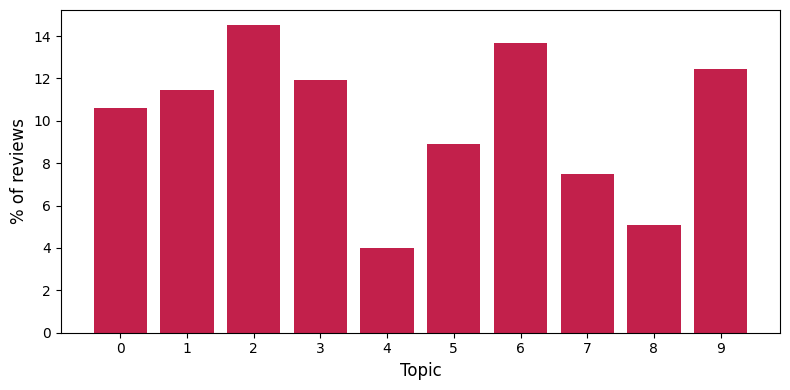

range 4.0%-14.5%  (n = 6501)


In [140]:
prevalence = annotated["topic_number"].value_counts(normalize=True).sort_index() * 100

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(prevalence.index, prevalence.values, color="#C2204B")
ax.set_xticks(prevalence.index)
ax.set_xlabel("Topic", fontsize=12)
ax.set_ylabel("% of reviews", fontsize=12)
fig.tight_layout()
plt.show()

print(f"range {prevalence.min():.1f}%-{prevalence.max():.1f}%  (n = {len(annotated)})")